# **Import Library**

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2
from glob import glob
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from scipy.stats import entropy
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.optimizers import Adam, RMSprop
import warnings
warnings.filterwarnings('ignore')

print("Library berhasil diimport")
print(f"🔹 TensorFlow version: {tf.__version__}")
print(f"🔹 GPU Available: {tf.config.list_physical_devices('GPU')}")

2026-05-05 13:51:07.761418: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777989067.998137      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777989068.062649      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777989068.604472      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777989068.604523      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777989068.604526      57 computation_placer.cc:177] computation placer alr

Library berhasil diimport
🔹 TensorFlow version: 2.19.0
🔹 GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


# **Ekplorasi Dataset**

In [2]:
base_path = '/kaggle/input/datasets/yahyaazz/data-9010/data'

train_dir = os.path.join(base_path, 'train')
val_dir = os.path.join(base_path, 'val')

### data perkelas

In [3]:

print("\n Struktur Folder:")

if os.path.exists(train_dir):
    classes = sorted([d for d in os.listdir(train_dir) 
                     if os.path.isdir(os.path.join(train_dir, d))])
    print(f"Kelas ditemukan: {classes}")
    print(f"Jumlah kelas: {len(classes)}\n")
    # Hitung jumlah data per kelas (gabungan train, val)
    print(" Jumlah Data per Kelas (Total Train + Val")
    print("-" * 70)
    print(f"{'Kelas':<30} {'Train':>8} {'Val':>8} {'Total':>10}")
    print("-" * 70)
    
    total_all_classes = 0
    class_totals = {}
    
    for class_name in classes:
        # Hitung di train
        train_class_path = os.path.join(train_dir, class_name)
        train_count = len([f for f in os.listdir(train_class_path) 
                          if os.path.isfile(os.path.join(train_class_path, f))]) if os.path.exists(train_class_path) else 0
        
        # Hitung di val
        val_class_path = os.path.join(val_dir, class_name)
        val_count = len([f for f in os.listdir(val_class_path) 
                        if os.path.isfile(os.path.join(val_class_path, f))]) if os.path.exists(val_class_path) else 0
        
        #jumlah total 
        total_class = train_count + val_count 
        class_totals[class_name] = total_class
        total_all_classes += total_class
        
        print(f"{class_name:<30} {train_count:>8} {val_count:>8} {total_class:>10}")
    
    print("-" * 70)
    print(f"{'TOTAL SEMUA KELAS':<30} {'':>8} {'':>8} {'':>8} {total_all_classes:>10}")
    


 Struktur Folder:
Kelas ditemukan: ['Leaf smut', 'bacterial_leaf_blight', 'bacterial_leaf_streak', 'bacterial_panicle_blight', 'blast', 'brown_spot', 'dead_heart', 'downy_mildew', 'hispa', 'normal', 'tungro']
Jumlah kelas: 11

 Jumlah Data per Kelas (Total Train + Val
----------------------------------------------------------------------
Kelas                             Train      Val      Total
----------------------------------------------------------------------
Leaf smut                           377       42        419
bacterial_leaf_blight               355       40        395
bacterial_leaf_streak               342       38        380
bacterial_panicle_blight            303       34        337
blast                               338       38        376
brown_spot                          345       39        384
dead_heart                          377       42        419
downy_mildew                        342       38        380
hispa                               369       41

### Distribusi Data

In [4]:
    print("\n ANALISIS KESEIMBANGAN DATA PER KELAS (Total Keseluruhan):")
    print("=" * 70)
    
    # Hitung metrik statistik
    class_names = list(class_totals.keys())
    total_values = list(class_totals.values())
    
    # Statistik dasar
    max_count = max(total_values)
    min_count = min(total_values)
    mean_count = sum(total_values) / len(total_values)

    # Hitung rasio
    max_min_ratio = max_count / min_count
    
    print(f"\n Statistik Distribusi Data:")
    print(f"   • Total data: {total_all_classes} gambar")
    print(f"   • Jumlah kelas: {len(classes)} kelas")
    print(f"   • Rata-rata per kelas: {mean_count:.2f} gambar")
    print(f"   • Kelas dengan data terbanyak: {max_count} gambar ({class_names[total_values.index(max_count)]})")
    print(f"   • Kelas dengan data tersedikit: {min_count} gambar ({class_names[total_values.index(min_count)]})")
    
    print(f"\n Rasio Perbandingan:")
    print(f"   • Rasio maks:min = {max_min_ratio:.2f} : 1")
    
    # Kategorisasi keseimbangan
    print(f"\n Kategori Keseimbangan Data:")
    if max_min_ratio <= 1.5:
        print("SANGAT SEIMBANG (rasio maks:min ≤ 1.5)")
    elif max_min_ratio <= 2:
        print("CUKUP SEIMBANG (1.5 < rasio maks:min ≤ 2)")
    elif max_min_ratio <= 3:
        print("KURANG SEIMBANG (2 < rasio maks:min ≤ 3)")
    else:
        print("  TIDAK SEIMBANG (rasio maks:min > 3)")
    


 ANALISIS KESEIMBANGAN DATA PER KELAS (Total Keseluruhan):

 Statistik Distribusi Data:
   • Total data: 4323 gambar
   • Jumlah kelas: 11 kelas
   • Rata-rata per kelas: 393.00 gambar
   • Kelas dengan data terbanyak: 420 gambar (normal)
   • Kelas dengan data tersedikit: 337 gambar (bacterial_panicle_blight)

 Rasio Perbandingan:
   • Rasio maks:min = 1.25 : 1

 Kategori Keseimbangan Data:
SANGAT SEIMBANG (rasio maks:min ≤ 1.5)


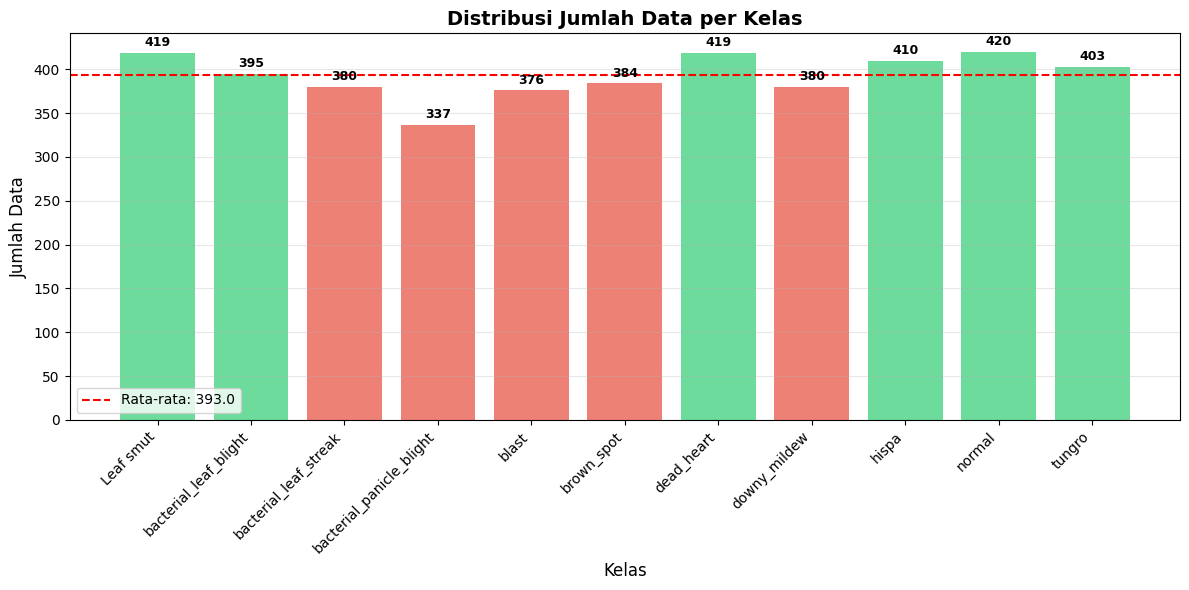

In [6]:
# BAR CHART - Distribusi Jumlah Data per Kelas
try:

    plt.figure(figsize=(12, 6))
    
    # Warna: hijau untuk di atas rata-rata, merah untuk di bawah rata-rata
    colors = ['#2ecc71' if x >= mean_count else '#e74c3c' for x in total_values]
    bars = plt.bar(class_names, total_values, color=colors, alpha=0.7)
    
    # Garis rata-rata
    plt.axhline(y=mean_count, color='r', linestyle='--', label=f'Rata-rata: {mean_count:.1f}')
    
    # Label dan judul
    plt.xlabel('Kelas', fontsize=12)
    plt.ylabel('Jumlah Data', fontsize=12)
    plt.title('Distribusi Jumlah Data per Kelas', fontsize=14, fontweight='bold')
    plt.legend()
    plt.xticks(rotation=45, ha='right')
    
    # Tambahkan nilai di atas bar
    for bar, val in zip(bars, total_values):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(total_values)*0.01, 
                str(val), ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
except ImportError:
    print("Diagram Error")

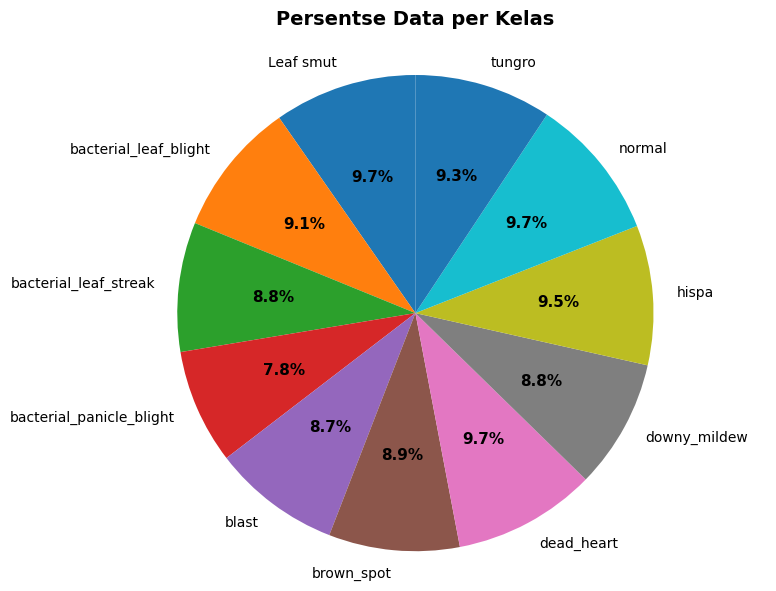

In [7]:
# PIE CHART - Proporsi Data per Kelas
try:
    plt.figure(figsize=(8, 6))
    
    # Buat pie chart
    wedges, texts, autotexts = plt.pie(total_values, 
                                        labels=class_names, 
                                        autopct='%1.1f%%', 
                                        startangle=90,
                                        textprops={'fontsize': 10})
    
    # Perbesar ukuran persentase
    for autotext in autotexts:
        autotext.set_fontsize(11)
        autotext.set_fontweight('bold')
    
    # Judul
    plt.title('Persentse Data per Kelas', fontsize=14, fontweight='bold', pad=20)
    
    # centre_circle = plt.Circle((0,0), 0.70, fc='white')
    # fig = plt.gcf()
    # fig.gca().add_artist(centre_circle)
    
    plt.axis('equal')  
    plt.tight_layout()
    plt.show()
    
except ImportError:
    print("Diagram Error")

### Dimensi & Resolusi

In [8]:
print("\n RATA-RATA DIMENSI SEMUA GAMBAR:")
print("=" * 50)
all_images = []
folders = [train_dir, val_dir]

for folder in folders:
    if os.path.exists(folder):
        for class_name in os.listdir(folder):
            class_path = os.path.join(folder, class_name)
            if os.path.isdir(class_path):
                for img_file in os.listdir(class_path):
                    all_images.append(os.path.join(class_path, img_file))

print(f" Total gambar: {len(all_images)}")

# Hitung dimensi
total_width = 0
total_height = 0
count = 0
widths = [] 
heights = [] 

for img_path in all_images:
    try:
        with Image.open(img_path) as img:
            w, h = img.size
            total_width += w
            total_height += h
            widths.append(w)
            heights.append(h)
            count += 1
    except Exception as e:
        print(f"Gagal baca {os.path.basename(img_path)}: {e}")

# Hasil
if count > 0:
    print(f"\n RATA-RATA DIMENSI:")
    print(f"   • Width  : {total_width/count:.1f} pixel")
    print(f"   • Height : {total_height/count:.1f} pixel")
    
    print(f"\n RENTANG DIMENSI:")
    print(f"   • Width  : {min(widths)} - {max(widths)} pixel")
    print(f"   • Height : {min(heights)} - {max(heights)} pixel")
    
    print(f"\n  Berdasarkan {count} gambar valid dari total {len(all_images)} gambar")
else:
    print("Tidak ada gambar valid")


 RATA-RATA DIMENSI SEMUA GAMBAR:
 Total gambar: 4323

 RATA-RATA DIMENSI:
   • Width  : 627.0 pixel
   • Height : 647.0 pixel

 RENTANG DIMENSI:
   • Width  : 72 - 4160 pixel
   • Height : 43 - 3120 pixel

  Berdasarkan 4323 gambar valid dari total 4323 gambar


### Karakteristik Dataset

In [9]:
print("\n ANALISIS KARAKTERISTIK DATASET")
print("=" * 70)

dataset_analysis = {}

for class_name in classes:
    class_path = os.path.join(train_dir, class_name)
    
    if not os.path.exists(class_path):
        continue
        
    images = [f for f in os.listdir(class_path) 
              if f.lower().endswith(('.png','.jpg','.jpeg'))]
    
    if len(images) == 0:
        continue
    
    brightness_list = []
    contrast_list = []
    sharpness_list = []
    entropy_list = []
    edge_density_list = []
    color_variance_list = []
    
    print(f"\n KELAS: {class_name}")
    print("-"*50)
    
    for img_name in images[:20]:  # ambil max 20 sampel biar cepat
        img_path = os.path.join(class_path, img_name)
        
        try:
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
            
            # 1. Brightness
            brightness = np.mean(gray)
            brightness_list.append(brightness)
            
            # 2. Contrast
            contrast = np.std(gray)
            contrast_list.append(contrast)
            
            # 3. Sharpness (Laplacian)
            sharpness = cv2.Laplacian(gray, cv2.CV_64F).var()
            sharpness_list.append(sharpness)
            
            # 4. Entropy (informasi)
            hist = np.histogram(gray, bins=256)[0]
            hist = hist / hist.sum()
            ent = entropy(hist + 1e-8)
            entropy_list.append(ent)
            
            # 5. Edge Density
            edges = cv2.Canny(gray, 100, 200)
            edge_density = np.sum(edges > 0) / edges.size
            edge_density_list.append(edge_density)
            
            # 6. Color Variance
            color_var = np.var(img)
            color_variance_list.append(color_var)
            
        except:
            continue
    
    # Simpan statistik
    dataset_analysis[class_name] = {
        "brightness": brightness_list,
        "contrast": contrast_list,
        "sharpness": sharpness_list,
        "entropy": entropy_list,
        "edge_density": edge_density_list,
        "color_variance": color_variance_list
    }
    
    # Print summary
    print(f" Brightness   : {np.mean(brightness_list):.2f} ± {np.std(brightness_list):.2f}")
    print(f" Contrast     : {np.mean(contrast_list):.2f}")
    print(f" Sharpness    : {np.mean(sharpness_list):.2f}")
    print(f" Entropy      : {np.mean(entropy_list):.2f}")
    print(f" Edge Density : {np.mean(edge_density_list):.4f}")
    print(f" Color Var    : {np.mean(color_variance_list):.2f}")


 ANALISIS KARAKTERISTIK DATASET

 KELAS: Leaf smut
--------------------------------------------------
 Brightness   : 182.73 ± 32.00
 Contrast     : 62.24
 Sharpness    : 169.37
 Entropy      : 3.67
 Edge Density : 0.0156
 Color Var    : 5434.86

 KELAS: bacterial_leaf_blight
--------------------------------------------------
 Brightness   : 132.40 ± 12.25
 Contrast     : 59.38
 Sharpness    : 3038.93
 Entropy      : 5.38
 Edge Density : 0.1965
 Color Var    : 5034.85

 KELAS: bacterial_leaf_streak
--------------------------------------------------
 Brightness   : 122.03 ± 5.78
 Contrast     : 62.41
 Sharpness    : 2842.73
 Entropy      : 5.39
 Edge Density : 0.1820
 Color Var    : 4925.67

 KELAS: bacterial_panicle_blight
--------------------------------------------------
 Brightness   : 129.02 ± 12.93
 Contrast     : 57.22
 Sharpness    : 1208.59
 Entropy      : 5.36
 Edge Density : 0.1293
 Color Var    : 4312.19

 KELAS: blast
--------------------------------------------------
 Bri

# **Data Preparaton**

### Data Split



 VISUALISASI PEMBAGIAN DATASET:
 Jumlah Gambar:
   • Train : 3888 gambar (89.9%)
   • Val   : 435 gambar (10.1%)
   • Total : 4323 gambar


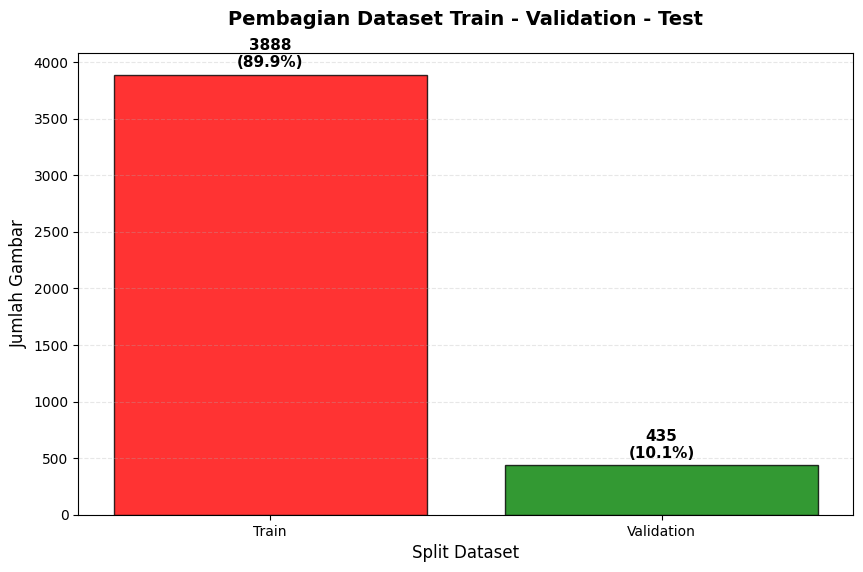

In [11]:
print("\n VISUALISASI PEMBAGIAN DATASET:")
print("=" * 50)

# Hitung jumlah gambar di setiap folder
train_count = 0
val_count = 0

# Hitung train
if os.path.exists(train_dir):
    for class_name in os.listdir(train_dir):
        class_path = os.path.join(train_dir, class_name)
        if os.path.isdir(class_path):
            train_count += len([f for f in os.listdir(class_path) 
                              if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff'))])

# Hitung val
if os.path.exists(val_dir):
    for class_name in os.listdir(val_dir):
        class_path = os.path.join(val_dir, class_name)
        if os.path.isdir(class_path):
            val_count += len([f for f in os.listdir(class_path) 
                            if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff'))])

total = train_count + val_count

# Visualisasi dengan bar chart
plt.figure(figsize=(10, 6))

# Data
folders = ['Train', 'Validation',]
counts = [train_count, val_count,]
colors = ['r', 'g', 'b']

# Bar chart
bars = plt.bar(folders, counts, color=colors, alpha=0.8, edgecolor='black', linewidth=1)

# Tambahkan nilai di atas bar
for bar, count in zip(bars, counts):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + max(counts)*0.01,
             f'{count}\n({count/total*100:.1f}%)', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Pengaturan plot
plt.title('Pembagian Dataset Train - Validation - Test', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Split Dataset', fontsize=12)
plt.ylabel('Jumlah Gambar', fontsize=12)
plt.grid(axis='y', alpha=0.3, linestyle='--')

print(f" Jumlah Gambar:")
print(f"   • Train : {train_count} gambar ({train_count/total*100:.1f}%)")
print(f"   • Val   : {val_count} gambar ({val_count/total*100:.1f}%)")
print(f"   • Total : {total} gambar")

### resizing

In [12]:
print("\n  RESIZING UNTUK SEMUA GAMBAR:")
print("=" * 60)

target_size = (224, 224)

# Fungsi untuk load dan resize gambar
def load_and_resize(image_path, target_size=(224, 224)):
    try:
        img = Image.open(image_path)
        if img.mode != 'RGB':
            img = img.convert('RGB')
        return img.resize(target_size)
    except Exception as e:
        print(f" Gagal: {os.path.basename(image_path)} - {e}")
        return None

# Kumpulkan semua path gambar
all_images = []
image_paths = []  # simpan path untuk referensi
labels = []       # simpan label

print(" Mengumpulkan path gambar...")
for split in ['train', 'val', 'test']:
    split_path = os.path.join(base_path, split)
    if os.path.exists(split_path):
        for class_name in os.listdir(split_path):
            class_path = os.path.join(split_path, class_name)
            if os.path.isdir(class_path):
                for img_file in os.listdir(class_path):
                    if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
                        img_path = os.path.join(class_path, img_file)
                        all_images.append(img_path)
                        image_paths.append(img_path)
                        labels.append(f"{split}_{class_name}")

print(f" Total gambar ditemukan: {len(all_images)}")

# Load dan resize semua gambar
print("\n Meload dan meresize semua gambar...")
resized_images = []

# Gunakan tqdm untuk progress bar
for img_path in tqdm(all_images, desc="Proses gambar"):
    img_resized = load_and_resize(img_path, target_size)
    if img_resized is not None:
        # Konversi ke numpy array
        img_array = np.array(img_resized)
        resized_images.append(img_array)

# Konversi ke numpy array
if resized_images:
    X = np.array(resized_images)
    
    print("\n" + "=" * 60)
    print(" RESIZING SELESAI!")
    print(f"   • Ukuran target: {target_size[0]} x {target_size[1]}")
    print(f"   • Total gambar berhasil: {len(resized_images)} dari {len(all_images)}")

else:
    print(" Tidak ada gambar yang berhasil diresize")


  RESIZING UNTUK SEMUA GAMBAR:
 Mengumpulkan path gambar...
 Total gambar ditemukan: 4323

 Meload dan meresize semua gambar...


Proses gambar: 100%|██████████| 4323/4323 [00:43<00:00, 99.89it/s] 



 RESIZING SELESAI!
   • Ukuran target: 224 x 224
   • Total gambar berhasil: 4323 dari 4323


### encoding

In [13]:
print("\n  ENCODING LABEL:")
print("=" * 30)

# Dapatkan daftar kelas dari folder train
classes = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])

# Buat mapping kelas ke angka
label_encoder = {class_name: i for i, class_name in enumerate(classes)}
label_decoder = {i: class_name for i, class_name in enumerate(classes)}

print(f"\n Ditemukan {len(classes)} kelas:")
for class_name, idx in label_encoder.items():
    print(f"   • {idx} : {class_name}")




  ENCODING LABEL:

 Ditemukan 11 kelas:
   • 0 : Leaf smut
   • 1 : bacterial_leaf_blight
   • 2 : bacterial_leaf_streak
   • 3 : bacterial_panicle_blight
   • 4 : blast
   • 5 : brown_spot
   • 6 : dead_heart
   • 7 : downy_mildew
   • 8 : hispa
   • 9 : normal
   • 10 : tungro


### Normalisasi 

In [14]:
print("\n NORMALISASI MIN-MAX (0-1):")
print("=" * 60)

# Cek apakah X sudah ada
if 'X' not in locals():
    print(" Loading X dari file...")
    try:
        X = np.load('/kaggle/working/resized_images.npy')
        print(f" Loaded: {X.shape}")
    except FileNotFoundError:
        print(" File tidak ditemukan! Jalankan resizing dulu.")
        exit()

print(f"\n Data BEFORE normalisasi:")
print(f"   • Shape: {X.shape}")
print(f"   • Tipe data: {X.dtype}")
print(f"   • Range: {X.min()} - {X.max()}")
print(f"   • Mean: {X.mean():.2f}")
print(f"   • Std: {X.std():.2f}")

# Normalisasi Min-Max ke 0-1
print("\n Melakukan normalisasi...")
X_normalized = X.astype(np.float32) / 255.0

print("\n Normalisasi selesai!")
print(f"\n Data Setelah normalisasi:")
print(f"   • Shape: {X_normalized.shape}")
print(f"   • Tipe data: {X_normalized.dtype}")
print(f"   • Range: {X_normalized.min():.4f} - {X_normalized.max():.4f}")
print(f"   • Mean: {X_normalized.mean():.4f}")
print(f"   • Std: {X_normalized.std():.4f}")

# Verifikasi
assert X_normalized.min() >= 0.0 and X_normalized.max() <= 1.0, "  Range tidak 0-1!"
print(f"\n Verifikasi: Nilai dalam rentang 0-1")



 NORMALISASI MIN-MAX (0-1):

 Data BEFORE normalisasi:
   • Shape: (4323, 224, 224, 3)
   • Tipe data: uint8
   • Range: 0 - 255
   • Mean: 117.17
   • Std: 72.38

 Melakukan normalisasi...

 Normalisasi selesai!

 Data Setelah normalisasi:
   • Shape: (4323, 224, 224, 3)
   • Tipe data: float32
   • Range: 0.0000 - 1.0000
   • Mean: 0.4595
   • Std: 0.2838

 Verifikasi: Nilai dalam rentang 0-1


### Augmentasi

In [15]:
sample_class = classes[0]
sample_path = os.path.join(train_dir, sample_class)
sample_image = os.listdir(sample_path)[0]
img_path = os.path.join(sample_path, sample_image)

# Load dan prep gambar
img = load_img(img_path, target_size=(224, 224))
img_array = img_to_array(img)
img_array = img_array.reshape((1,) + img_array.shape)

#### Flip


1️ FLIP (SESUAI TRAIN DATAGEN):


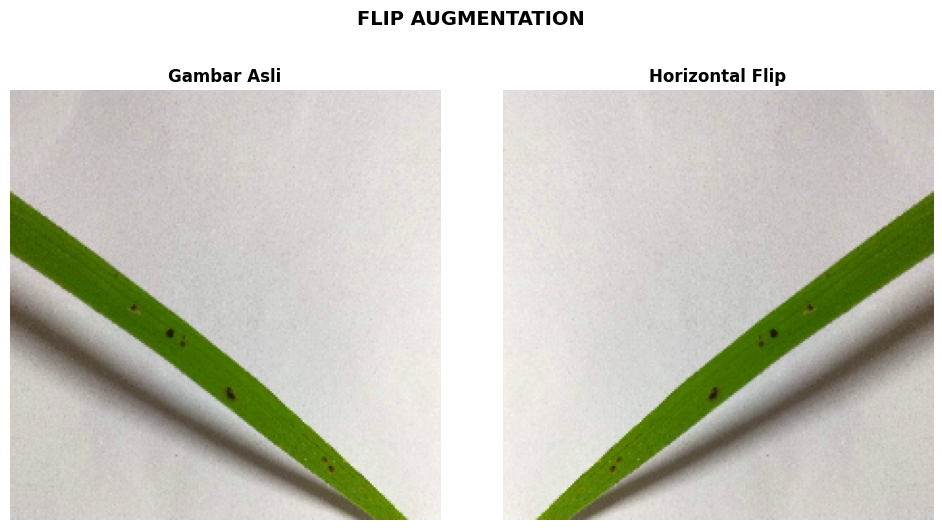

In [16]:
print("\n" + "=" * 60)
print("1️ FLIP (SESUAI TRAIN DATAGEN):")
print("=" * 60)

flip_datagen = ImageDataGenerator(
    horizontal_flip=True,
    vertical_flip=False   # disesuaikan
)

# Generate gambar dengan flip
flip_iter = flip_datagen.flow(img_array, batch_size=1)

plt.figure(figsize=(10, 5))

# Gambar asli
plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Gambar Asli", fontsize=12, fontweight='bold')
plt.axis('off')

# Horizontal flip
plt.subplot(1, 2, 2)
horizontal_flip = next(flip_iter)[0].astype('uint8')
plt.imshow(horizontal_flip)
plt.title("Horizontal Flip", fontsize=12, fontweight='bold')
plt.axis('off')

plt.suptitle("FLIP AUGMENTATION", fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

#### Zoom


 ZOOM:


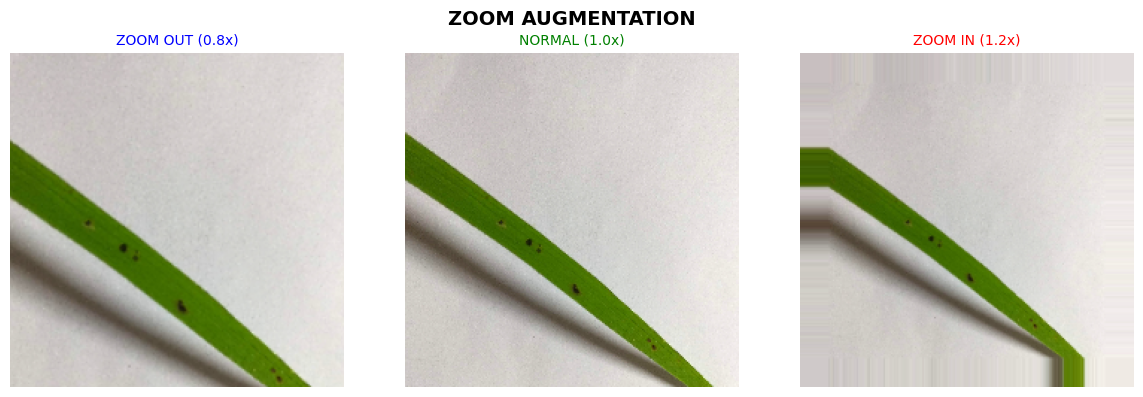

In [ ]:
print("\n" + "=" * 60)
print(" ZOOM:")
print("=" * 60)

zoom_datagen = ImageDataGenerator(
    zoom_range=0.2 
)

plt.figure(figsize=(12, 4))

zoom_levels = [
    (0.8, "ZOOM OUT (0.8x)", "blue"),
    (1.0, "NORMAL (1.0x)", "green"),
    (1.2, "ZOOM IN (1.2x)", "red")
]

for i, (zoom_val, label, color) in enumerate(zoom_levels):
    plt.subplot(1, 3, i+1)
    
    # Set zoom fix (biar deterministik)
    temp_datagen = ImageDataGenerator(zoom_range=[zoom_val, zoom_val])
    zoom_iter = temp_datagen.flow(img_array, batch_size=1)
    zoom_img = next(zoom_iter)[0].astype('uint8')
    
    plt.imshow(zoom_img)
    plt.title(label, fontsize=10, color=color)
    plt.axis('off')
    
    # Border biar clean
    for spine in plt.gca().spines.values():
        spine.set_color(color)
        spine.set_linewidth(2)

plt.suptitle("ZOOM AUGMENTATION", 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Blur


 BLUR:


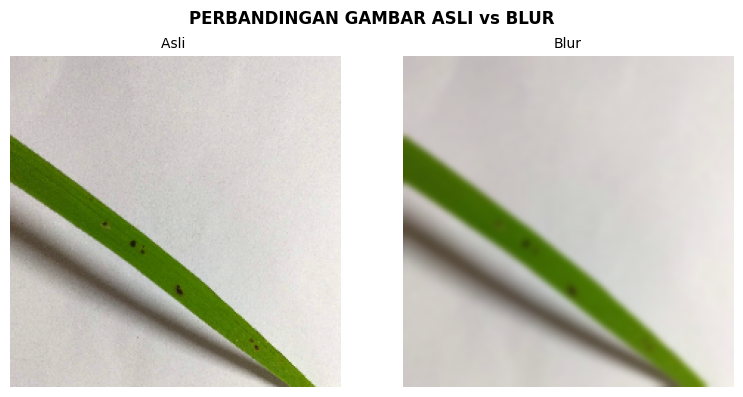

In [16]:
# ============================================
# 6. BLUR (menggunakan OpenCV)
# ============================================
print("\n" + "=" * 60)
print(" BLUR:")
print("=" * 60)

img_cv = cv2.cvtColor(np.array(img), cv2.COLOR_RGB2BGR)

plt.figure(figsize=(8, 4))

# Hanya dua level: Asli dan Blur Ekstrim
blur_levels = [
    (0, "Asli "),
    (11, "Blur")
]

for i, (kernel_size, label) in enumerate(blur_levels):
    plt.subplot(1, 2, i+1)
    
    if kernel_size == 0:
        plt.imshow(cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB))
    else:
        # Aplikasikan Gaussian blur
        blurred = cv2.GaussianBlur(img_cv, (kernel_size, kernel_size), 0)
        blurred_rgb = cv2.cvtColor(blurred, cv2.COLOR_BGR2RGB)
        plt.imshow(blurred_rgb)
    
    plt.title(label, fontsize=10, fontweight='normal')
    plt.axis('off')

plt.suptitle("PERBANDINGAN GAMBAR ASLI vs BLUR", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### Brightness


 BRIGHTNESS:


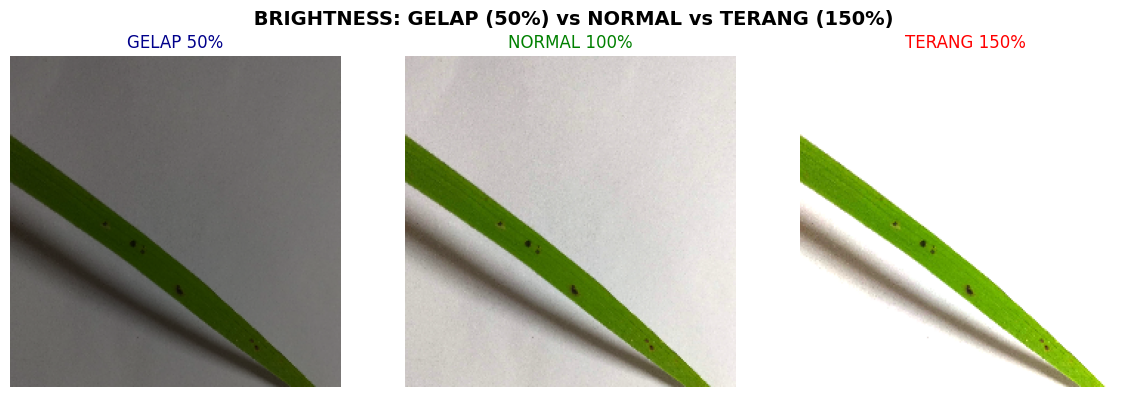

In [17]:
# ============================================
# 5. BRIGHTNESS
# ============================================
print("\n" + "=" * 60)
print(" BRIGHTNESS:")
print("=" * 60)

brightness_datagen = ImageDataGenerator(
    brightness_range=[0.5, 1.5] 
)

plt.figure(figsize=(12, 4))


brightness_levels = [
    (0.5, "GELAP 50%", "darkblue"),
    (1.0, "NORMAL 100%", "green"),
    (1.5, "TERANG 150%", "red")
]

for i, (bright, label, color) in enumerate(brightness_levels):
    plt.subplot(1, 3, i+1)
    
    brightness_datagen.brightness_range = [bright, bright]
    brightness_iter = brightness_datagen.flow(img_array, batch_size=1)
    bright_img = next(brightness_iter)[0].astype('uint8')
    
    plt.imshow(bright_img)
    plt.title(label, fontsize=12, fontweight='normal', color=color)
    plt.axis('off')
    
    # Tambah border
    for spine in plt.gca().spines.values():
        spine.set_color(color)
        spine.set_linewidth(3)

plt.suptitle(" BRIGHTNESS: GELAP (50%) vs NORMAL vs TERANG (150%)", 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### Rotation


ROTATION AUGMENTATION:


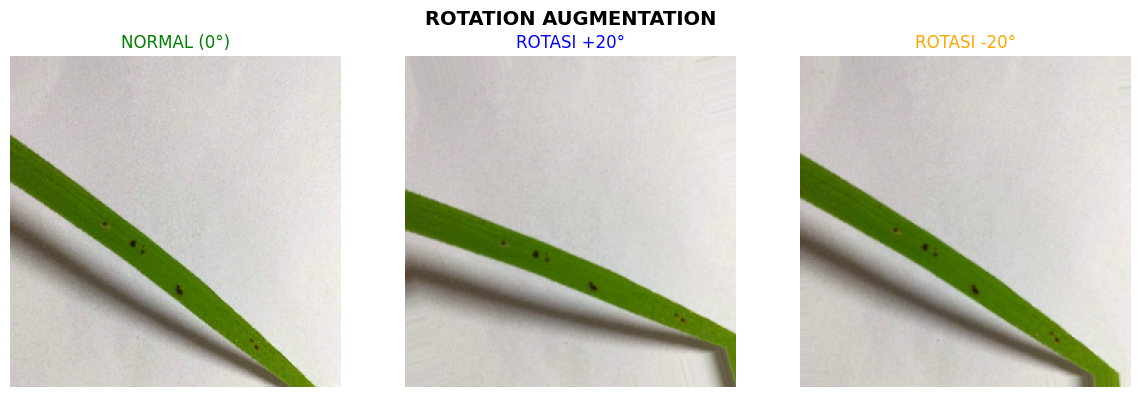

In [24]:
print("\n" + "=" * 60)
print("ROTATION AUGMENTATION:")
print("=" * 60)

plt.figure(figsize=(12, 4))

rotations = [
    (0, "NORMAL (0°)", "green"),
    (20, "ROTASI +20°", "blue"),
    (-20, "ROTASI -20°", "orange")
]

for i, (angle, label, color) in enumerate(rotations):
    plt.subplot(1, 3, i+1)
    
    if angle == 0:
        rot_img = img
    else:
        # Trick: range kecil biar mendekati sudut tertentu
        temp_datagen = ImageDataGenerator(rotation_range=abs(angle))
        rot_iter = temp_datagen.flow(img_array, batch_size=1)
        rot_img = next(rot_iter)[0].astype('uint8')
    
    plt.imshow(rot_img)
    plt.title(label, fontsize=12, color=color)
    plt.axis('off')
    
    for spine in plt.gca().spines.values():
        spine.set_color(color)
        spine.set_linewidth(2)

plt.suptitle("ROTATION AUGMENTATION", 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Shift


4️⃣ SHIFT AUGMENTATION:


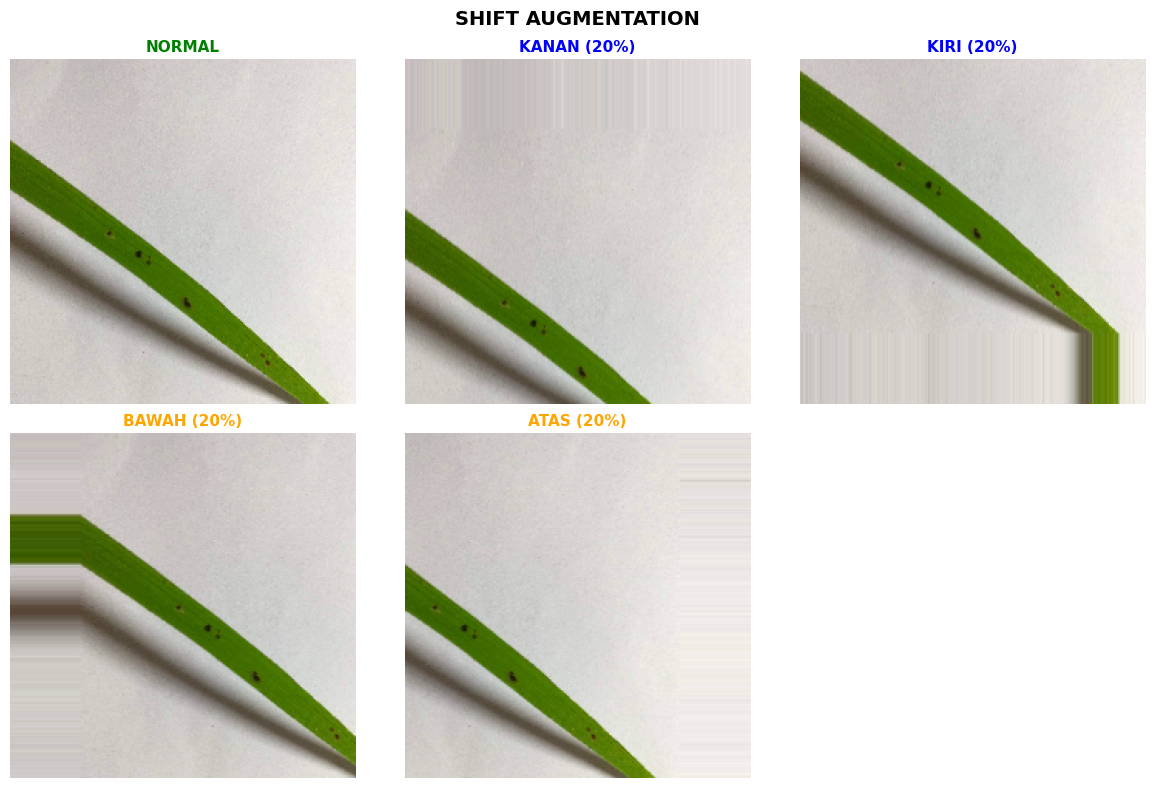

In [25]:
print("\n" + "=" * 60)
print("4️⃣ SHIFT AUGMENTATION:")
print("=" * 60)

plt.figure(figsize=(12, 8))

shifts = [
    ((0, 0), "NORMAL", "green"),
    ((0.2, 0), "KANAN (20%)", "blue"),
    ((-0.2, 0), "KIRI (20%)", "blue"),
    ((0, 0.2), "BAWAH (20%)", "orange"),
    ((0, -0.2), "ATAS (20%)", "orange"),
]

for i, ((w_shift, h_shift), label, color) in enumerate(shifts):
    plt.subplot(2, 3, i+1)
    
    if w_shift == 0 and h_shift == 0:
        shift_img = img
    else:
        # Trick: pakai range kecil biar mendekati arah tertentu
        temp_datagen = ImageDataGenerator(
            width_shift_range=[w_shift, w_shift],
            height_shift_range=[h_shift, h_shift],
            fill_mode='nearest'
        )
        shift_iter = temp_datagen.flow(img_array, batch_size=1)
        shift_img = next(shift_iter)[0].astype('uint8')
    
    plt.imshow(shift_img)
    plt.title(label, fontsize=11, fontweight='bold', color=color)
    
    for spine in plt.gca().spines.values():
        spine.set_color(color)
        spine.set_linewidth(2)
    
    plt.axis('off')

plt.suptitle("SHIFT AUGMENTATION", 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


 SHEAR AUGMENTATION:


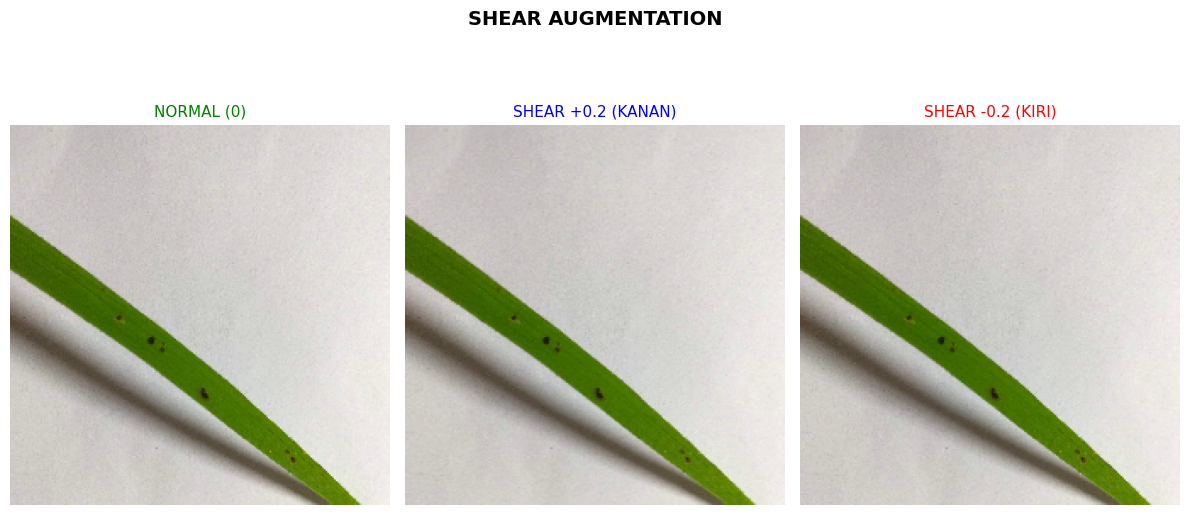

In [33]:
print("\n" + "=" * 60)
print(" SHEAR AUGMENTATION:")
print("=" * 60)

plt.figure(figsize=(12, 6))

shear_values = [
    (0, "NORMAL (0)", "green"),
    (0.2, "SHEAR +0.2 (KANAN)", "blue"),
    (-0.2, "SHEAR -0.2 (KIRI)", "red"),
]

for i, (shear_val, label, color) in enumerate(shear_values):
    plt.subplot(1, 3, i+1)
    
    if shear_val == 0:
        shear_img = img
    else:
        # Trick: range kecil biar mendekati nilai tertentu
        temp_datagen = ImageDataGenerator(
            shear_range=abs(shear_val)
        )
        shear_iter = temp_datagen.flow(img_array, batch_size=1)
        shear_img = next(shear_iter)[0].astype('uint8')
    
    plt.imshow(shear_img)
    plt.title(label, fontsize=11, color=color)
    plt.axis('off')
    
    for spine in plt.gca().spines.values():
        spine.set_color(color)
        spine.set_linewidth(2)

plt.suptitle("SHEAR AUGMENTATION", 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [30]:

IMG_SIZE = 224  
BATCH_SIZE = 32  

train_datagen = ImageDataGenerator(
    rescale=1./255,              
    rotation_range=20,           
    width_shift_range=0.2,        
    height_shift_range=0.2,       
    shear_range=0.2,              
    zoom_range=0.2,               
    horizontal_flip=True,         
    vertical_flip=False,     
    fill_mode='nearest'           
)
val_test_datagen = ImageDataGenerator(rescale=1./255)

print(f" Parameter:")
print(f"  • Image size: {IMG_SIZE}x{IMG_SIZE}")
print(f"  • Batch size: {BATCH_SIZE}")

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    classes=classes,
    seed=42
)

validation_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    classes=classes,
    seed=42
)

print("\n data generators complete...")

 Parameter:
  • Image size: 224x224
  • Batch size: 32
Found 3888 images belonging to 11 classes.
Found 435 images belonging to 11 classes.

 data generators complete...


# *Modeling*

In [ ]:
# ============================================
# STEP 5: BUILD CNN FROM SCRATCH
# ============================================

def create_cnn_model(input_shape, num_classes):
    """
    Membangun model CNN dari awal dengan arsitektur yang dirancang khusus
    untuk deteksi penyakit daun padi
    """
    model = models.Sequential([
        # Block 1 - Fitur dasar (tepi, sudut, tekstur sederhana)
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', 
                     input_shape=input_shape,
                     kernel_regularizer=regularizers.l2(0.0001)),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                     kernel_regularizer=regularizers.l2(0.0001)),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(0.25),
        
        # Block 2 - Fitur menengah (bentuk, pola)
        layers.Conv2D(64, (3, 3), activation='relu', padding='same',
                     kernel_regularizer=regularizers.l2(0.0001)),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same',
                     kernel_regularizer=regularizers.l2(0.0001)),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(0.25),
        
        # Block 3 - Fitur kompleks (tekstur penyakit)
        layers.Conv2D(128, (3, 3), activation='relu', padding='same',
                     kernel_regularizer=regularizers.l2(0.0001)),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3, 3), activation='relu', padding='same',
                     kernel_regularizer=regularizers.l2(0.0001)),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(0.25),
        
        # Block 4 - Fitur sangat kompleks
        layers.Conv2D(256, (3, 3), activation='relu', padding='same',
                     kernel_regularizer=regularizers.l2(0.0001)),
        layers.BatchNormalization(),
        layers.Conv2D(256, (3, 3), activation='relu', padding='same',
                     kernel_regularizer=regularizers.l2(0.0001)),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(0.25),
        
        # Classification head
        layers.Flatten(),
        layers.Dense(512, activation='relu', 
                    kernel_regularizer=regularizers.l2(0.0001)),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        
        layers.Dense(256, activation='relu',
                    kernel_regularizer=regularizers.l2(0.0001)),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        
        # Output layer
        layers.Dense(num_classes, activation='softmax')
    ])
    
    return model

# Buat model
input_shape = (IMG_SIZE, IMG_SIZE, 3)
num_classes = len(classes)

model = create_cnn_model(input_shape, num_classes)

# Compile model
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Tampilkan arsitektur
print("\n MODEL ARCHITECTURE:")
model.summary()


I0000 00:00:1777904946.013044      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777904946.018912      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5



 MODEL ARCHITECTURE:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 27,003,947 (103.01 MB)

 Trainable params: 27,000,491 (103.00 MB)

 Non-trainable params: 3,456 (13.50 KB)

In [23]:
# ============================================
# STEP 7: TRAINING MODEL
# ============================================

# Callbacks
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    
    ModelCheckpoint(
        'model.h5',
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=7,
        min_lr=1e-7,
        verbose=1
    )
]

# Training configuration
steps_per_epoch = train_generator.samples // BATCH_SIZE
validation_steps = validation_generator.samples // BATCH_SIZE

print(" TRAINING CONFIGURATION:")
print(f"Epochs: 100 (with early stopping)")
print(f"Batch size: {BATCH_SIZE}")
print(f"Steps per epoch: {steps_per_epoch}")
print(f"Validation steps: {validation_steps}")

# Jalankan training
history = model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    epochs=100,
    validation_data=validation_generator,
    validation_steps=validation_steps,
    callbacks=callbacks,
    verbose=1
)

print("\n Training selesai!")

 TRAINING CONFIGURATION:
Epochs: 100 (with early stopping)
Batch size: 32
Steps per epoch: 121
Validation steps: 13
Epoch 1/100


I0000 00:00:1777904955.804393     127 service.cc:152] XLA service 0x7f40f8016600 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777904955.804445     127 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777904955.804451     127 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777904957.158384     127 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-04 14:29:24.553787: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-04 14:29:24.708108: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-04 14:29:27.694894: E external/local_xl

  6/121 ━━━━━━━━━━━━━━━━━━━━ 50s 441ms/step - accuracy: 0.1267 - loss: 3.5776

2026-05-04 14:29:48.456786: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-04 14:29:48.606520: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-04 14:29:50.055365: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-04 14:29:50.326204: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 598ms/step - accuracy: 0.2165 - loss: 2.9685
Epoch 1: val_accuracy improved from -inf to 0.02644, saving model to model.h5


...

121/121 ━━━━━━━━━━━━━━━━━━━━ 60s 492ms/step - accuracy: 0.8232 - loss: 0.9770 - val_accuracy: 0.8654 - val_loss: 0.9126 - learning_rate: 1.2500e-04
Epoch 72/100
  1/121 ━━━━━━━━━━━━━━━━━━━━ 25s 211ms/step - accuracy: 0.7188 - loss: 1.1364
Epoch 72: val_accuracy did not improve from 0.86538
121/121 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.7188 - loss: 1.1364 - val_accuracy: 0.8654 - val_loss: 0.9182 - learning_rate: 1.2500e-04
Epoch 73/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 469ms/step - accuracy: 0.8325 - loss: 0.9379
Epoch 73: val_accuracy did not improve from 0.86538
121/121 ━━━━━━━━━━━━━━━━━━━━ 59s 486ms/step - accuracy: 0.8325 - loss: 0.9381 - val_accuracy: 0.8582 - val_loss: 0.9322 - learning_rate: 1.2500e-04
Epoch 74/100
  1/121 ━━━━━━━━━━━━━━━━━━━━ 23s 200ms/step - accuracy: 0.7812 - loss: 1.1364
Epoch 74: val_accuracy did not improve from 0.86538
121/121 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.7812 - loss: 1.1364 - val_accuracy: 0.8558 - val_loss: 0.9391 - learning_r

121/121 ━━━━━━━━━━━━━━━━━━━━ 60s 491ms/step - accuracy: 0.8450 - loss: 0.8802 - val_accuracy: 0.8750 - val_loss: 0.8883 - learning_rate: 6.2500e-05
Epoch 80/100
  1/121 ━━━━━━━━━━━━━━━━━━━━ 25s 210ms/step - accuracy: 0.8125 - loss: 0.8158
Epoch 80: val_accuracy did not improve from 0.87500
121/121 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.8125 - loss: 0.8158 - val_accuracy: 0.8750 - val_loss: 0.8878 - learning_rate: 6.2500e-05
Epoch 81/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 467ms/step - accuracy: 0.8713 - loss: 0.8435
Epoch 81: val_accuracy improved from 0.87500 to 0.89423, saving model to model.h5


121/121 ━━━━━━━━━━━━━━━━━━━━ 60s 494ms/step - accuracy: 0.8713 - loss: 0.8436 - val_accuracy: 0.8942 - val_loss: 0.8326 - learning_rate: 6.2500e-05
Epoch 82/100
  1/121 ━━━━━━━━━━━━━━━━━━━━ 24s 207ms/step - accuracy: 0.9375 - loss: 0.6909
Epoch 82: val_accuracy did not improve from 0.89423
121/121 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.9375 - loss: 0.6909 - val_accuracy: 0.8918 - val_loss: 0.8362 - learning_rate: 6.2500e-05
Epoch 83/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 462ms/step - accuracy: 0.8729 - loss: 0.8324
Epoch 83: val_accuracy did not improve from 0.89423
121/121 ━━━━━━━━━━━━━━━━━━━━ 58s 479ms/step - accuracy: 0.8729 - loss: 0.8324 - val_accuracy: 0.8654 - val_loss: 0.8899 - learning_rate: 6.2500e-05
Epoch 84/100
  1/121 ━━━━━━━━━━━━━━━━━━━━ 23s 196ms/step - accuracy: 0.8750 - loss: 0.9256
Epoch 84: val_accuracy did not improve from 0.89423
121/121 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.8750 - loss: 0.9256 - val_accuracy: 0.8606 - val_loss: 0.8969 - learning_r

121/121 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.8750 - loss: 0.7404 - val_accuracy: 0.8966 - val_loss: 0.7922 - learning_rate: 3.1250e-05
Epoch 95/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 468ms/step - accuracy: 0.8850 - loss: 0.7870
Epoch 95: val_accuracy did not improve from 0.89663
121/121 ━━━━━━━━━━━━━━━━━━━━ 59s 486ms/step - accuracy: 0.8850 - loss: 0.7871 - val_accuracy: 0.8894 - val_loss: 0.8082 - learning_rate: 3.1250e-05
Epoch 96/100
  1/121 ━━━━━━━━━━━━━━━━━━━━ 23s 198ms/step - accuracy: 0.8750 - loss: 0.8065
Epoch 96: val_accuracy did not improve from 0.89663
121/121 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.8750 - loss: 0.8065 - val_accuracy: 0.8894 - val_loss: 0.8105 - learning_rate: 3.1250e-05
Epoch 97/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 473ms/step - accuracy: 0.8893 - loss: 0.7681
Epoch 97: val_accuracy did not improve from 0.89663
121/121 ━━━━━━━━━━━━━━━━━━━━ 59s 490ms/step - accuracy: 0.8893 - loss: 0.7682 - val_accuracy: 0.8942 - val_loss: 0.8325 - learning_ra

121/121 ━━━━━━━━━━━━━━━━━━━━ 60s 494ms/step - accuracy: 0.8906 - loss: 0.7692 - val_accuracy: 0.9087 - val_loss: 0.7835 - learning_rate: 3.1250e-05
Epoch 100/100
  1/121 ━━━━━━━━━━━━━━━━━━━━ 25s 216ms/step - accuracy: 0.9062 - loss: 0.7573
Epoch 100: val_accuracy did not improve from 0.90865
121/121 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.9062 - loss: 0.7573 - val_accuracy: 0.9087 - val_loss: 0.7827 - learning_rate: 3.1250e-05
Restoring model weights from the end of the best epoch: 100.

 Training selesai!


# *Evaluation*

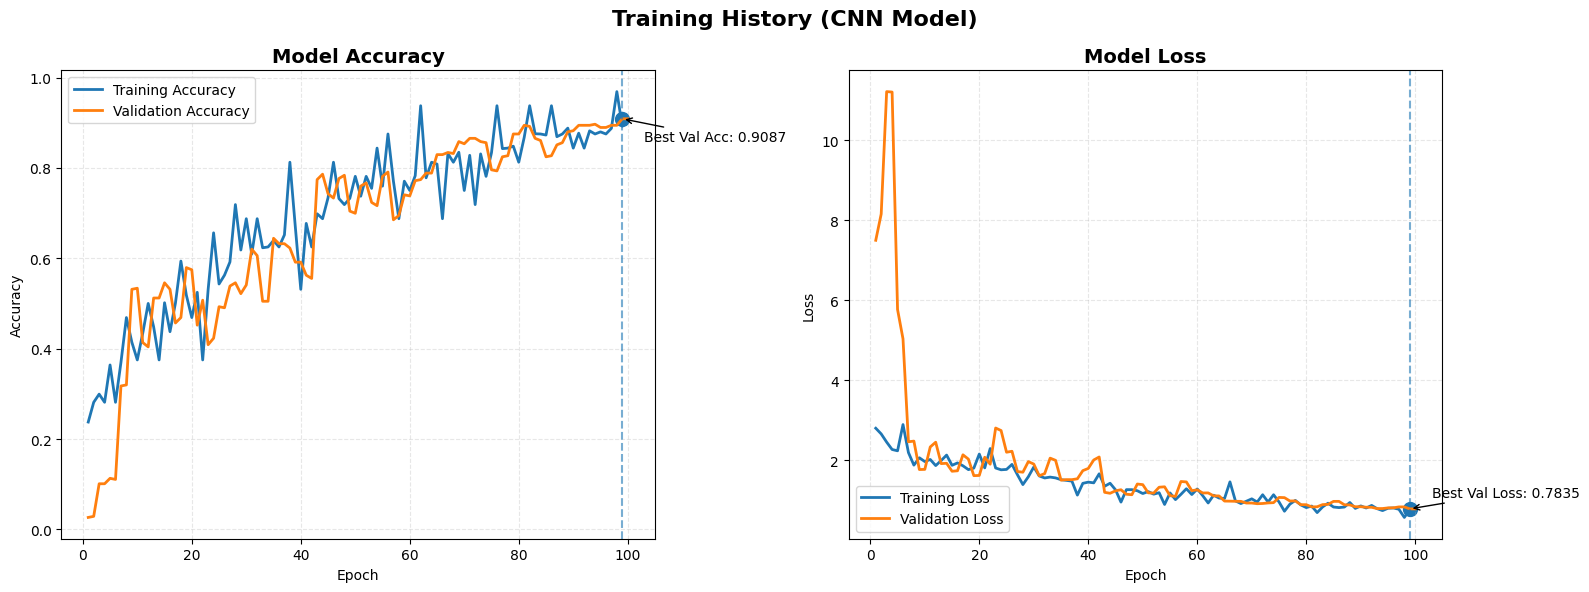

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# Cari epoch terbaik (berdasarkan val_accuracy tertinggi)
best_epoch = np.argmax(history.history['val_accuracy'])
best_val_acc = history.history['val_accuracy'][best_epoch]
best_val_loss = history.history['val_loss'][best_epoch]

epochs = range(1, len(history.history['accuracy']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ============================================
# ACCURACY PLOT
# ============================================
axes[0].plot(epochs, history.history['accuracy'], 
             label='Training Accuracy', linewidth=2)
axes[0].plot(epochs, history.history['val_accuracy'], 
             label='Validation Accuracy', linewidth=2)

# Highlight best point
axes[0].scatter(best_epoch + 1, best_val_acc, s=100)
axes[0].axvline(x=best_epoch + 1, linestyle='--', alpha=0.6)

# Annotation
axes[0].annotate(f'Best Val Acc: {best_val_acc:.4f}',
                 xy=(best_epoch + 1, best_val_acc),
                 xytext=(best_epoch + 5, best_val_acc - 0.05),
                 arrowprops=dict(arrowstyle='->'))

axes[0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.3)

# ============================================
# LOSS PLOT
# ============================================
axes[1].plot(epochs, history.history['loss'], 
             label='Training Loss', linewidth=2)
axes[1].plot(epochs, history.history['val_loss'], 
             label='Validation Loss', linewidth=2)

# Highlight best loss
axes[1].scatter(best_epoch + 1, best_val_loss, s=100)
axes[1].axvline(x=best_epoch + 1, linestyle='--', alpha=0.6)

# Annotation
axes[1].annotate(f'Best Val Loss: {best_val_loss:.4f}',
                 xy=(best_epoch + 1, best_val_loss),
                 xytext=(best_epoch + 5, best_val_loss + 0.3),
                 arrowprops=dict(arrowstyle='->'))

axes[1].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.3)

plt.suptitle('Training History (CNN Model)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

 Model berhasil di-load!
14/14 ━━━━━━━━━━━━━━━━━━━━ 9s 498ms/step - accuracy: 0.9347 - loss: 0.6866

 Validation Accuracy: 0.9057 (90.57%)
 Validation Loss: 0.7899
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 184ms/step

 CLASSIFICATION REPORT:
                          precision    recall  f1-score   support

               Leaf smut       1.00      1.00      1.00        42
   bacterial_leaf_blight       0.97      0.93      0.95        40
   bacterial_leaf_streak       0.93      0.97      0.95        38
bacterial_panicle_blight       0.97      0.91      0.94        34
                   blast       0.82      0.87      0.85        38
              brown_spot       0.87      0.85      0.86        39
              dead_heart       0.89      0.98      0.93        42
            downy_mildew       0.77      0.79      0.78        38
                   hispa       0.93      0.93      0.93        41
                  normal       0.93      0.90      0.92        42
                  tungro       0.89      0.

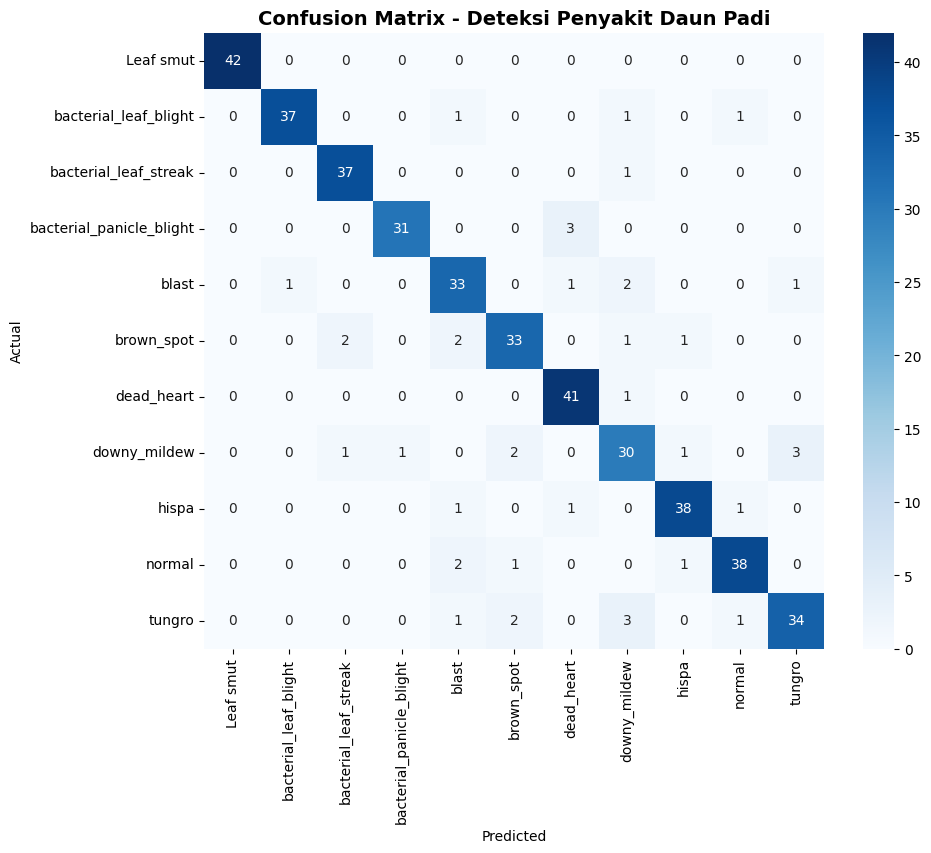

In [26]:

best_model = tf.keras.models.load_model('model.h5')
print(" Model berhasil di-load!")

if 'validation_generator' not in dir():
    from tensorflow.keras.preprocessing.image import ImageDataGenerator
    
    val_datagen = ImageDataGenerator(rescale=1./255)
    
    validation_generator = val_datagen.flow_from_directory(
        '/kaggle/input/datasets/yahyaazz/data-9010/data/val',
        target_size=(224, 224),
        batch_size=32,
        class_mode='categorical',
        shuffle=False 
    )

# Evaluasi
val_loss, val_accuracy = best_model.evaluate(validation_generator, verbose=1)
print(f"\n Validation Accuracy: {val_accuracy:.4f} ({val_accuracy*100:.2f}%)")
print(f" Validation Loss: {val_loss:.4f}")

validation_generator.reset()
predictions = best_model.predict(validation_generator)
y_pred = np.argmax(predictions, axis=1)
y_true = validation_generator.classes

# Dapatkan nama kelas
classes = list(validation_generator.class_indices.keys())

print("\n CLASSIFICATION REPORT:")
print(classification_report(y_true, y_pred, target_names=classes))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix - Deteksi Penyakit Daun Padi', fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

✅ Model berhasil di-load!


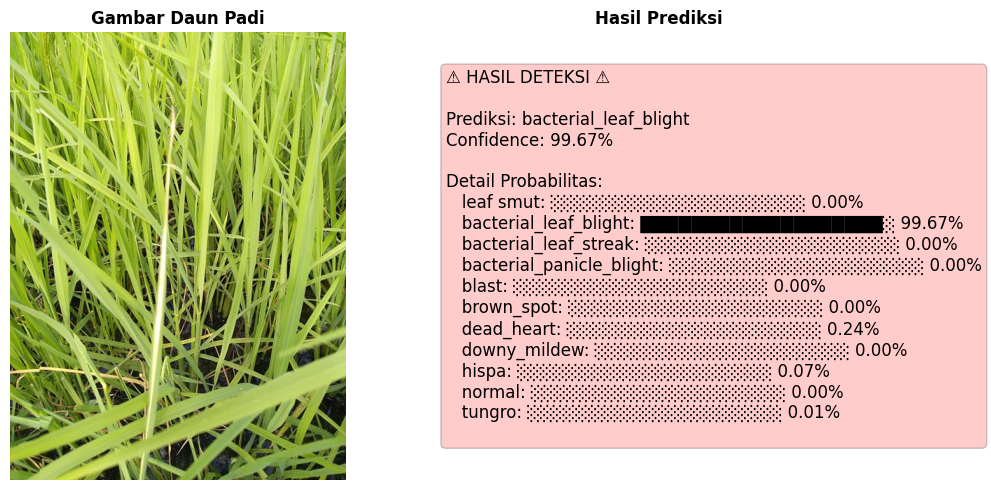


📊 HASIL PREDIKSI
📁 Gambar: /kaggle/input/datasets/yahyaazz/data-9010/data/val/bacterial_leaf_blight/100126.jpg
🎯 Prediksi: bacterial_leaf_blight
📈 Confidence: 99.67% (0.9967)

📋 Detail Probabilitas per Kelas:
   leaf smut: 0.0000 (0.00%)
   bacterial_leaf_blight: 0.9967 (99.67%)
   bacterial_leaf_streak: 0.0000 (0.00%)
   bacterial_panicle_blight: 0.0000 (0.00%)
   blast: 0.0000 (0.00%)
   brown_spot: 0.0000 (0.00%)
   dead_heart: 0.0024 (0.24%)
   downy_mildew: 0.0000 (0.00%)
   hispa: 0.0007 (0.07%)
   normal: 0.0000 (0.00%)
   tungro: 0.0001 (0.01%)

🔬 PREDIKSI INTERAKTIF

Masukkan path gambar (atau ketik 'quit' untuk keluar):


>>  /kaggle/input/datasets/yahyaazz/data-7030/data/val/blast/100004.jpg



🎯 Hasil: blast
📈 Confidence: 95.25%

Detail:
   leaf smut: 0.00%
   bacterial_leaf_blight: 0.08%
   bacterial_leaf_streak: 0.05%
   bacterial_panicle_blight: 0.00%
   blast: 95.25%
   brown_spot: 0.04%
   dead_heart: 4.48%
   downy_mildew: 0.00%
   hispa: 0.04%
   normal: 0.04%
   tungro: 0.01%

Masukkan path gambar (atau ketik 'quit' untuk keluar):


>>  /kaggle/input/datasets/yahyaazz/data-7030/data/val/Leaf smut/DSC_0505.jpg



🎯 Hasil: leaf smut
📈 Confidence: 99.75%

Detail:
   leaf smut: 99.75%
   bacterial_leaf_blight: 0.10%
   bacterial_leaf_streak: 0.00%
   bacterial_panicle_blight: 0.01%
   blast: 0.00%
   brown_spot: 0.00%
   dead_heart: 0.10%
   downy_mildew: 0.01%
   hispa: 0.01%
   normal: 0.01%
   tungro: 0.00%

Masukkan path gambar (atau ketik 'quit' untuk keluar):


...


🎯 Hasil: downy_mildew
📈 Confidence: 99.30%

Detail:
   leaf smut: 0.00%
   bacterial_leaf_blight: 0.00%
   bacterial_leaf_streak: 0.00%
   bacterial_panicle_blight: 0.00%
   blast: 0.00%
   brown_spot: 0.00%
   dead_heart: 0.00%
   downy_mildew: 99.30%
   hispa: 0.00%
   normal: 0.00%
   tungro: 0.70%

Masukkan path gambar (atau ketik 'quit' untuk keluar):


>>  /kaggle/input/datasets/yahyaazz/data-7030/data/val/brown_spot/100361.jpg



🎯 Hasil: brown_spot
📈 Confidence: 90.77%

Detail:
   leaf smut: 0.01%
   bacterial_leaf_blight: 1.01%
   bacterial_leaf_streak: 0.39%
   bacterial_panicle_blight: 0.02%
   blast: 4.08%
   brown_spot: 90.77%
   dead_heart: 0.02%
   downy_mildew: 1.18%
   hispa: 0.35%
   normal: 0.08%
   tungro: 2.10%

Masukkan path gambar (atau ketik 'quit' untuk keluar):


>>  /kaggle/input/datasets/yahyaazz/data-7030/data/val/brown_spot/100410.jpg



🎯 Hasil: brown_spot
📈 Confidence: 99.77%

Detail:
   leaf smut: 0.00%
   bacterial_leaf_blight: 0.01%
   bacterial_leaf_streak: 0.00%
   bacterial_panicle_blight: 0.00%
   blast: 0.00%
   brown_spot: 99.77%
   dead_heart: 0.00%
   downy_mildew: 0.01%
   hispa: 0.00%
   normal: 0.00%
   tungro: 0.21%

Masukkan path gambar (atau ketik 'quit' untuk keluar):


In [ ]:
# ============================================
# STEP 9: PREDIKSI GAMBAR BARU (SINGLE IMAGE)
# ============================================

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import load_model

# ============================================
# 1. LOAD MODEL TERBAIK
# ============================================

best_model = load_model('model.h5')
print("✅ Model berhasil di-load!")

# Daftar kelas (sesuaikan dengan kelas Anda)
classes = ['leaf smut', 'bacterial_leaf_blight', 'bacterial_leaf_streak', 'bacterial_panicle_blight','blast', 'brown_spot', 'dead_heart', 'downy_mildew', 'hispa', 'normal', 'tungro']  # Urutan sesuai training

# ============================================
# 2. FUNGSI PREDIKSI GAMBAR
# ============================================

def predict_image(image_path, model, img_size=224, class_names=classes):
    """
    Memprediksi penyakit daun padi dari gambar
    
    Parameters:
    - image_path: path ke gambar yang akan diprediksi
    - model: model CNN yang sudah dilatih
    - img_size: ukuran gambar (default 224)
    - class_names: daftar nama kelas
    
    Returns:
    - predicted_class: nama kelas yang diprediksi
    - confidence: tingkat keyakinan (0-1)
    - all_probabilities: probabilitas untuk semua kelas
    """
    
    # Load dan preprocess gambar
    img = load_img(image_path, target_size=(img_size, img_size))
    img_array = img_to_array(img)
    img_array = img_array / 255.0  # Normalisasi
    img_array = np.expand_dims(img_array, axis=0)  # Tambahkan batch dimension
    
    # Prediksi
    predictions = model.predict(img_array, verbose=0)[0]
    
    # Hasil
    predicted_idx = np.argmax(predictions)
    predicted_class = class_names[predicted_idx]
    confidence = float(predictions[predicted_idx])
    
    all_probabilities = {
        class_names[i]: float(predictions[i]) 
        for i in range(len(class_names))
    }
    
    return predicted_class, confidence, all_probabilities

# ============================================
# 3. FUNGSI TAMPILKAN HASIL PREDIKSI
# ============================================

def display_prediction(image_path, predicted_class, confidence, all_probabilities):
    """
    Menampilkan gambar dan hasil prediksi
    """
    # Load gambar untuk ditampilkan
    img = load_img(image_path)
    
    # Setup figure
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # Tampilkan gambar
    ax1.imshow(img)
    ax1.set_title(f'Gambar Daun Padi', fontsize=12, fontweight='bold')
    ax1.axis('off')
    
    # Tampilkan hasil prediksi
    if predicted_class == 'Sehat':
        color = 'green'
        icon = '✅'
    else:
        color = 'red'
        icon = '⚠️'
    
    result_text = f"{icon} HASIL DETEKSI {icon}\n\n"
    result_text += f"Prediksi: {predicted_class}\n"
    result_text += f"Confidence: {confidence:.2%}\n\n"
    result_text += "Detail Probabilitas:\n"
    
    for class_name, prob in all_probabilities.items():
        bar_length = int(prob * 20)
        bar = '█' * bar_length + '░' * (20 - bar_length)
        result_text += f"   {class_name}: {bar} {prob:.2%}\n"
    
    ax2.text(0.1, 0.5, result_text, transform=ax2.transAxes,
             fontsize=12, verticalalignment='center',
             bbox=dict(boxstyle='round', facecolor=color, alpha=0.2))
    ax2.set_title('Hasil Prediksi', fontsize=12, fontweight='bold')
    ax2.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Print ke console
    print("\n" + "="*50)
    print("📊 HASIL PREDIKSI")
    print("="*50)
    print(f"📁 Gambar: {image_path}")
    print(f"🎯 Prediksi: {predicted_class}")
    print(f"📈 Confidence: {confidence:.2%} ({confidence:.4f})")
    print("\n📋 Detail Probabilitas per Kelas:")
    for class_name, prob in all_probabilities.items():
        print(f"   {class_name}: {prob:.4f} ({prob*100:.2f}%)")
    print("="*50)

# ============================================
# 4. UJI COBA DENGAN SATU GAMBAR
# ============================================

# Ganti dengan path gambar yang ingin Anda uji
image_path = '/kaggle/input/datasets/yahyaazz/data-9010/data/val/bacterial_leaf_blight/100126.jpg'  # ← GANTI DENGAN PATH GAMBAR ANDA

try:
    # Prediksi
    predicted_class, confidence, all_probabilities = predict_image(image_path, best_model)
    
    # Tampilkan hasil
    display_prediction(image_path, predicted_class, confidence, all_probabilities)
    
except FileNotFoundError:
    print(f"❌ File tidak ditemukan: {image_path}")
    print("   Silakan periksa kembali path gambar Anda.")
except Exception as e:
    print(f"❌ Error: {e}")

# ============================================
# 6. PREDIKSI INTERAKTIF (Input dari User)
# ============================================

print("\n" + "="*50)
print("🔬 PREDIKSI INTERAKTIF")
print("="*50)

while True:
    print("\nMasukkan path gambar (atau ketik 'quit' untuk keluar):")
    user_input = input(">> ").strip()
    
    if user_input.lower() == 'quit':
        print("👋 Keluar dari program...")
        break
    
    try:
        pred_class, confidence, probs = predict_image(user_input, best_model)
        print(f"\n🎯 Hasil: {pred_class}")
        print(f"📈 Confidence: {confidence:.2%}")
        print("\nDetail:")
        for cls, prob in probs.items():
            print(f"   {cls}: {prob:.2%}")
    except FileNotFoundError:
        print(f"❌ File tidak ditemukan: {user_input}")
    except Exception as e:
        print(f"❌ Error: {e}")

In [ ]:
model.save('deteksi.h5')